In [5]:
import numpy as np
img = np.random.rand(28,28)
vector = img.flatten()
print(vector.shape)

(784,)


正在通过 Scikit-Learn 加载 MNIST 数据集 (首次运行需下载约 50MB)...
成功找到 6313 张数字 '5' 的图像。
正在拟合 784 维高斯模型...
均值向量 mu 形状: (784,)
协方差矩阵 Sigma 形状: (784, 784)
正在从模型中采样生成新图像...


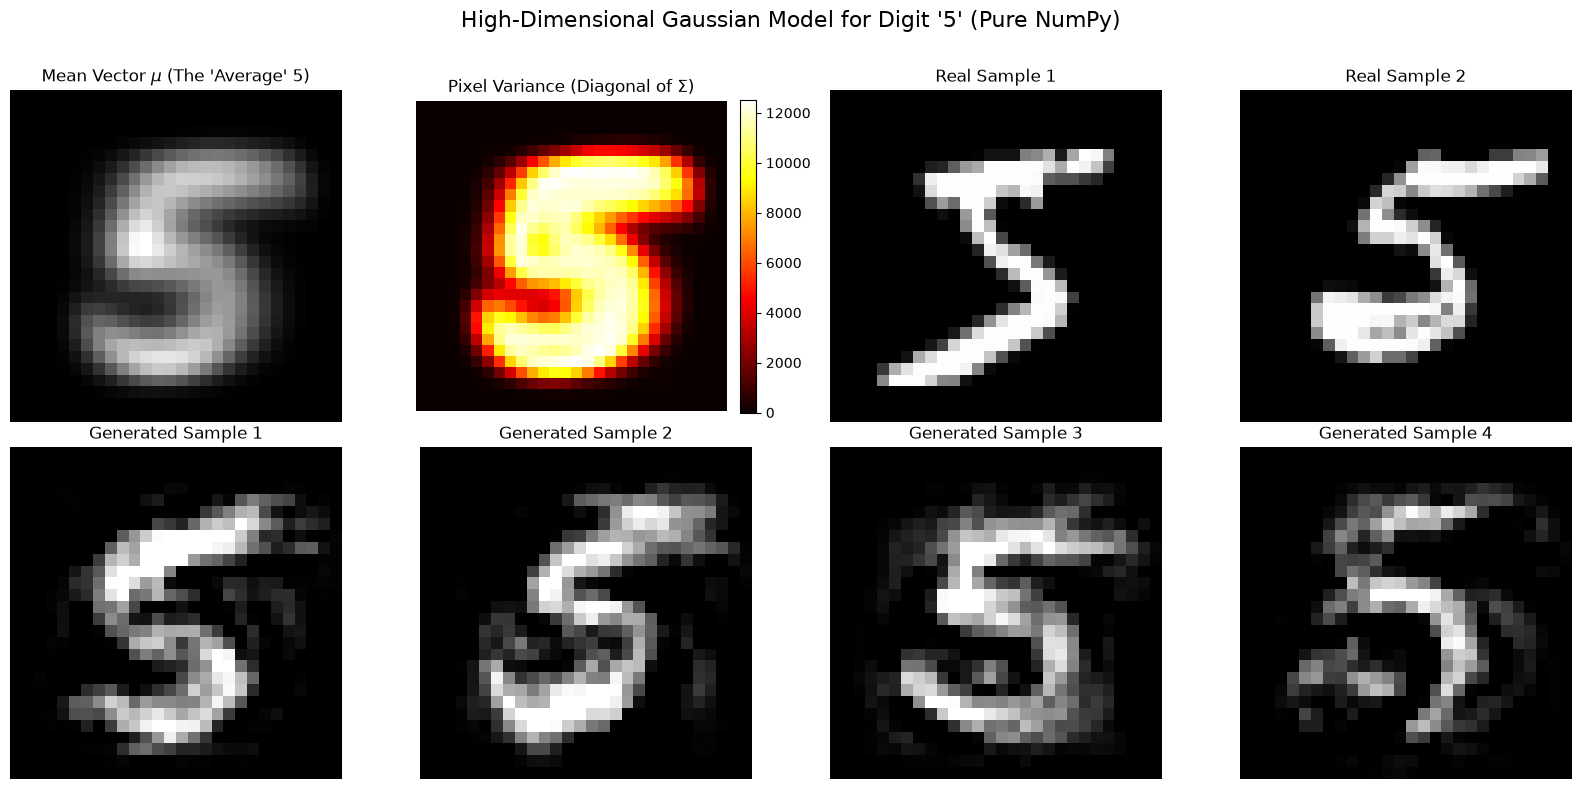

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# ==========================================
# 1. 加载数据并筛选数字 "5"
# ==========================================
print("正在通过 Scikit-Learn 加载 MNIST 数据集 (首次运行需下载约 50MB)...")
# as_frame=False 确保返回的是 NumPy 数组而不是 Pandas DataFrame
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X = mnist.data    # 形状: (70000, 784)，已经是展平的 784 维向量
y = mnist.target  # 形状: (70000,)，注意：sklearn 读取的标签是字符串类型 '0'-'9'

# 筛选出标签为 '5' 的图像，并转换为 float64 保证矩阵运算精度
X_5 = X[y == '5'].astype(np.float64)
print(f"成功找到 {X_5.shape[0]} 张数字 '5' 的图像。")

# ==========================================
# 2. 拟合高维高斯模型 (参数估计)
# ==========================================
print("正在拟合 784 维高斯模型...")

# 计算均值向量 mu (784维)
mu = np.mean(X_5, axis=0)

# 计算协方差矩阵 Sigma (784 x 784)
# rowvar=False 表示每一列代表一个特征(像素)，每一行代表一个样本
Sigma = np.cov(X_5, rowvar=False) 

# 【关键步骤】正则化协方差矩阵 (Ridge Regularization)
# 原因：MNIST 图像四个角的像素几乎永远是 0（纯黑），方差为 0；
# 且 784 维中存在大量线性相关的像素，导致原始协方差矩阵是奇异的（不可逆，无法进行 Cholesky 分解）。
# 我们在对角线上加上一个微小的常数使其成为正定矩阵。
epsilon = 1e-2 
Sigma_reg = Sigma + np.eye(784) * epsilon

print(f"均值向量 mu 形状: {mu.shape}")
print(f"协方差矩阵 Sigma 形状: {Sigma_reg.shape}")

# ==========================================
# 3. 从拟合的模型中采样 (生成新的数字 5)
# ==========================================
print("正在从模型中采样生成新图像...")

# 使用 Cholesky 分解进行高效采样
# 原理：若 z ~ N(0, I)，且 Sigma = L * L^T，则 x = mu + L * z 服从 N(mu, Sigma)
try:
    L = np.linalg.cholesky(Sigma_reg)
    num_samples = 5
    z = np.random.randn(num_samples, 784) # 生成标准正态噪声
    samples = mu + z @ L.T                # 矩阵乘法生成样本
except np.linalg.LinAlgError:
    print("Cholesky 分解失败，回退到 SVD 采样...")
    U, S, Vt = np.linalg.svd(Sigma_reg)
    L = U * np.sqrt(S)
    z = np.random.randn(5, 784)
    samples = mu + z @ L.T

# ==========================================
# 4. 可视化结果
# ==========================================
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("High-Dimensional Gaussian Model for Digit '5' (Pure NumPy)", fontsize=16)

# --- 第一行：模型参数与真实数据 ---
# 1. 均值图像 (Mean Image) - 所有数字5的“平均脸”
axes[0, 0].imshow(mu.reshape(28, 28), cmap='gray')
axes[0, 0].set_title("Mean Vector $\mu$ (The 'Average' 5)")
axes[0, 0].axis('off')

# 2. 方差图像 (Variance Image) - 展示哪些像素变化最大
# 提取协方差矩阵的对角线元素即为各个像素的方差
variance = np.diag(Sigma).reshape(28, 28) 
im = axes[0, 1].imshow(variance, cmap='hot')
axes[0, 1].set_title("Pixel Variance (Diagonal of $\Sigma$)")
axes[0, 1].axis('off')
fig.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)

# 3 & 4. 随机挑选两张真实的数字 5 作为对比
axes[0, 2].imshow(X_5[0].reshape(28, 28), cmap='gray')
axes[0, 2].set_title("Real Sample 1")
axes[0, 2].axis('off')

axes[0, 3].imshow(X_5[100].reshape(28, 28), cmap='gray')
axes[0, 3].set_title("Real Sample 2")
axes[0, 3].axis('off')

# --- 第二行：从模型中生成的样本 ---
for i in range(4):
    # 将生成的向量裁剪到 0-255 范围并转回 uint8 以便显示
    generated_img = np.clip(samples[i], 0, 255).reshape(28, 28)
    axes[1, i].imshow(generated_img, cmap='gray')
    axes[1, i].set_title(f"Generated Sample {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

加载 MNIST 数据集...
共 6313 张数字 '5'。


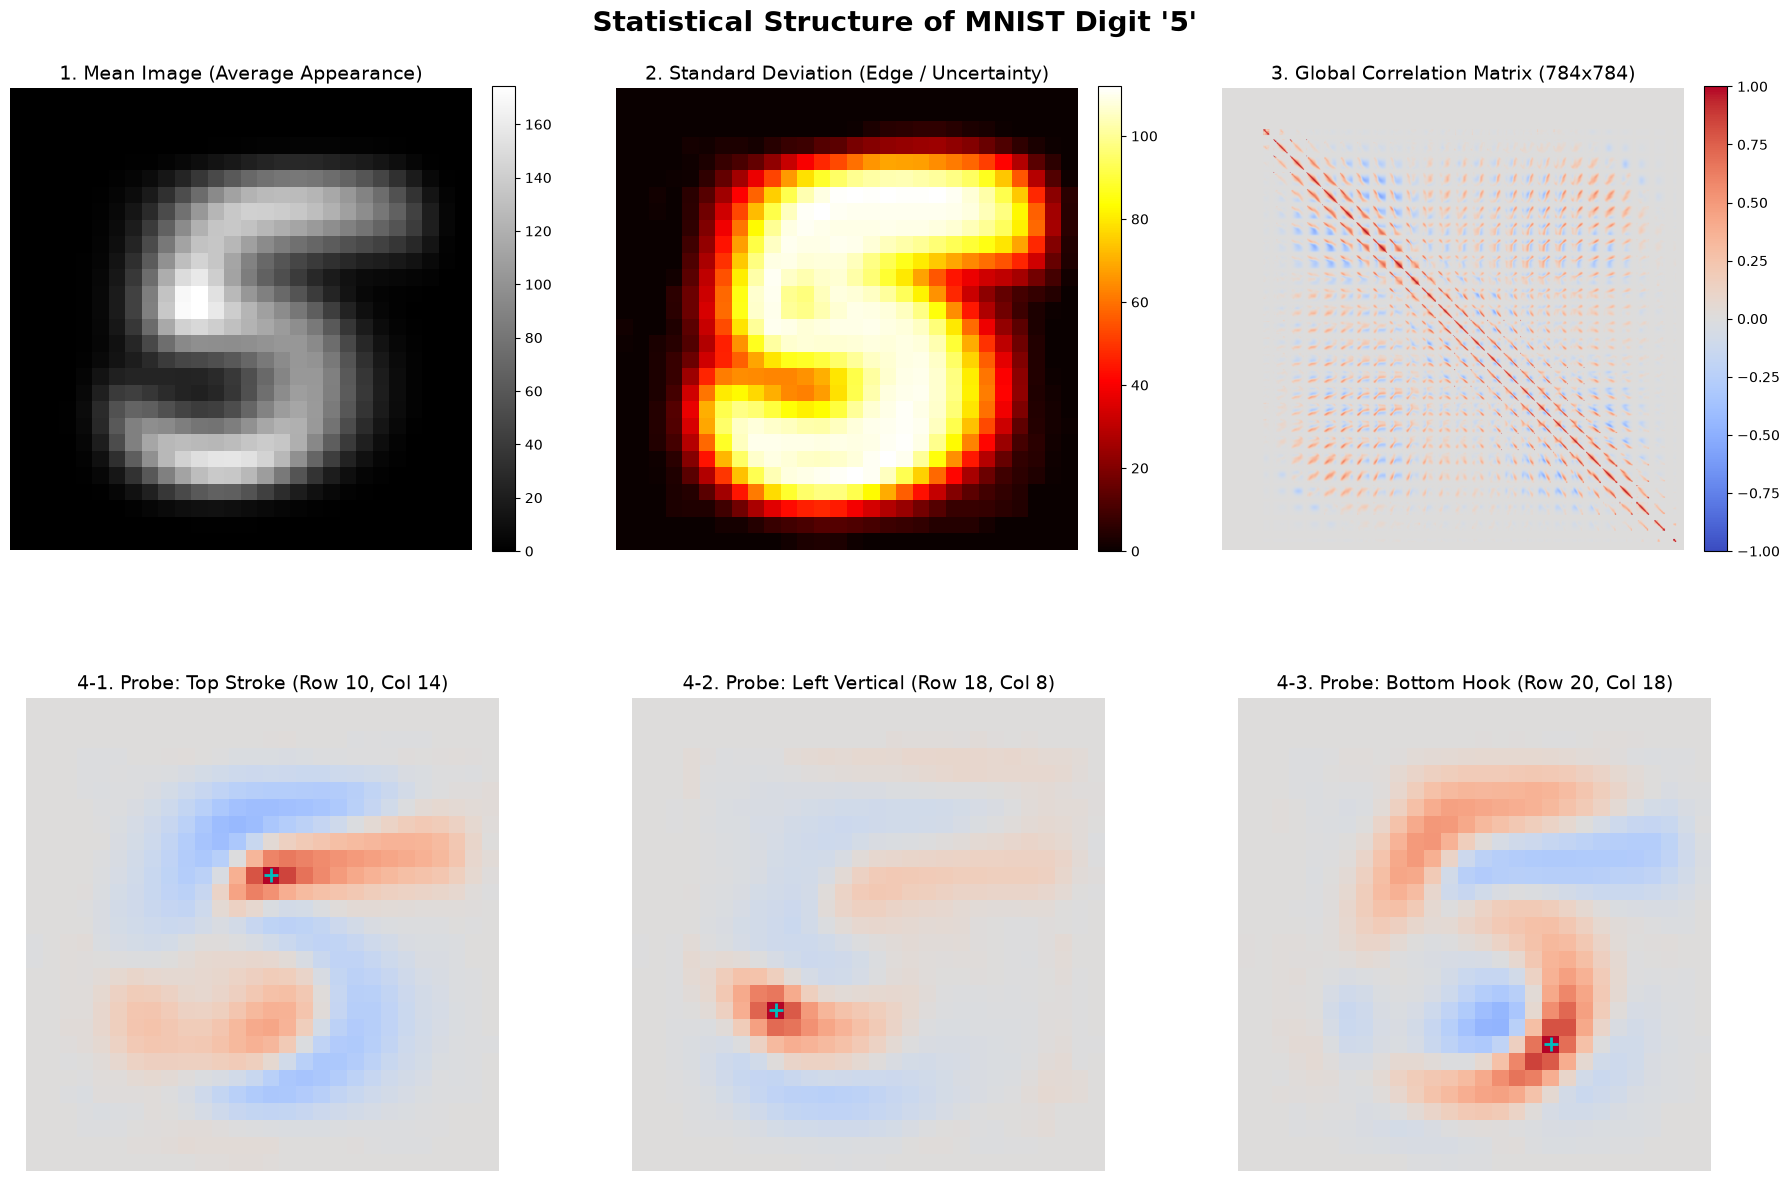

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# 1. 加载数据并筛选数字 "5"
print("加载 MNIST 数据集...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X = mnist.data[mnist.target == '5'].astype(np.float64)
print(f"共 {X.shape[0]} 张数字 '5'。")

# 2. 计算统计量
mu = np.mean(X, axis=0)                  # 均值向量 (784,)
std = np.std(X, axis=0)                  # 标准差向量 (784,)

# 计算相关系数矩阵 (比协方差矩阵更适合可视化，因为归一化到了 [-1, 1])
# 为了避免除以0，过滤掉标准差为0的纯黑背景像素
valid_idx = std > 1e-5
X_valid = X[:, valid_idx]
std_valid = std[valid_idx]
mu_valid = mu[valid_idx]

# 计算相关系数矩阵 (N x N)
corr_matrix = np.corrcoef(X_valid, rowvar=False)

# 将相关系数矩阵映射回 784x784 的完整矩阵 (背景像素相关系数设为0)
full_corr = np.zeros((784, 784))
full_corr[np.ix_(valid_idx, valid_idx)] = corr_matrix

# ==========================================
# 可视化部分
# ==========================================
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Statistical Structure of MNIST Digit '5'", fontsize=20, fontweight='bold')

# --- 图1：均值图 ---
ax1 = fig.add_subplot(2, 3, 1)
im1 = ax1.imshow(mu.reshape(28, 28), cmap='gray')
ax1.set_title("1. Mean Image (Average Appearance)", fontsize=14)
ax1.axis('off')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# --- 图2：标准差图 ---
ax2 = fig.add_subplot(2, 3, 2)
im2 = ax2.imshow(std.reshape(28, 28), cmap='hot')
ax2.set_title("2. Standard Deviation (Edge / Uncertainty)", fontsize=14)
ax2.axis('off')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# --- 图3：全局相关系数热图 (784x784) ---
ax3 = fig.add_subplot(2, 3, 3)
im3 = ax3.imshow(full_corr, cmap='coolwarm', vmin=-1, vmax=1)
ax3.set_title("3. Global Correlation Matrix (784x784)", fontsize=14)
ax3.axis('off')
fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

# --- 图4, 5, 6：单像素相关性映射 (深度解析局部与全局结构) ---
# 我们挑选3个具有代表性的像素点，观察它们与全图其他像素的相关性
# 像素坐标 (row, col) -> 一维索引 idx = row * 28 + col
probe_pixels = [
    (10, 14, "Probe: Top Stroke"),    # 顶部横线附近
    (18, 8, "Probe: Left Vertical"),  # 左侧竖线附近
    (20, 18, "Probe: Bottom Hook")    # 底部弯钩附近
]

for i, (r, c, title) in enumerate(probe_pixels):
    ax = fig.add_subplot(2, 3, 4 + i)
    
    idx = r * 28 + c
    # 提取该像素与所有其他像素的相关系数，并重塑为 28x28
    corr_map = full_corr[idx, :].reshape(28, 28)
    
    # 绘制相关性图
    im = ax.imshow(corr_map, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_title(f"4-{i+1}. {title} (Row {r}, Col {c})", fontsize=14)
    
    # 在图上用十字标记选中的探测像素
    ax.plot(c, r, 'c+', markersize=10, markeredgewidth=2)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.2)
plt.show()

加载 MNIST 数据集...
为每个数字拟合高斯分布...


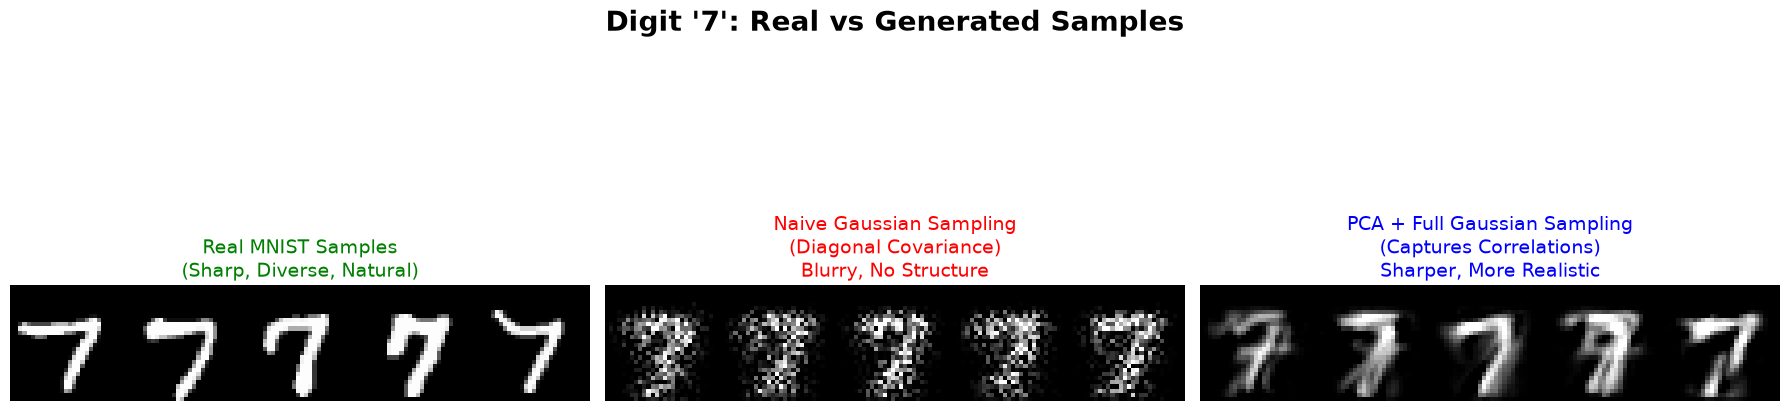

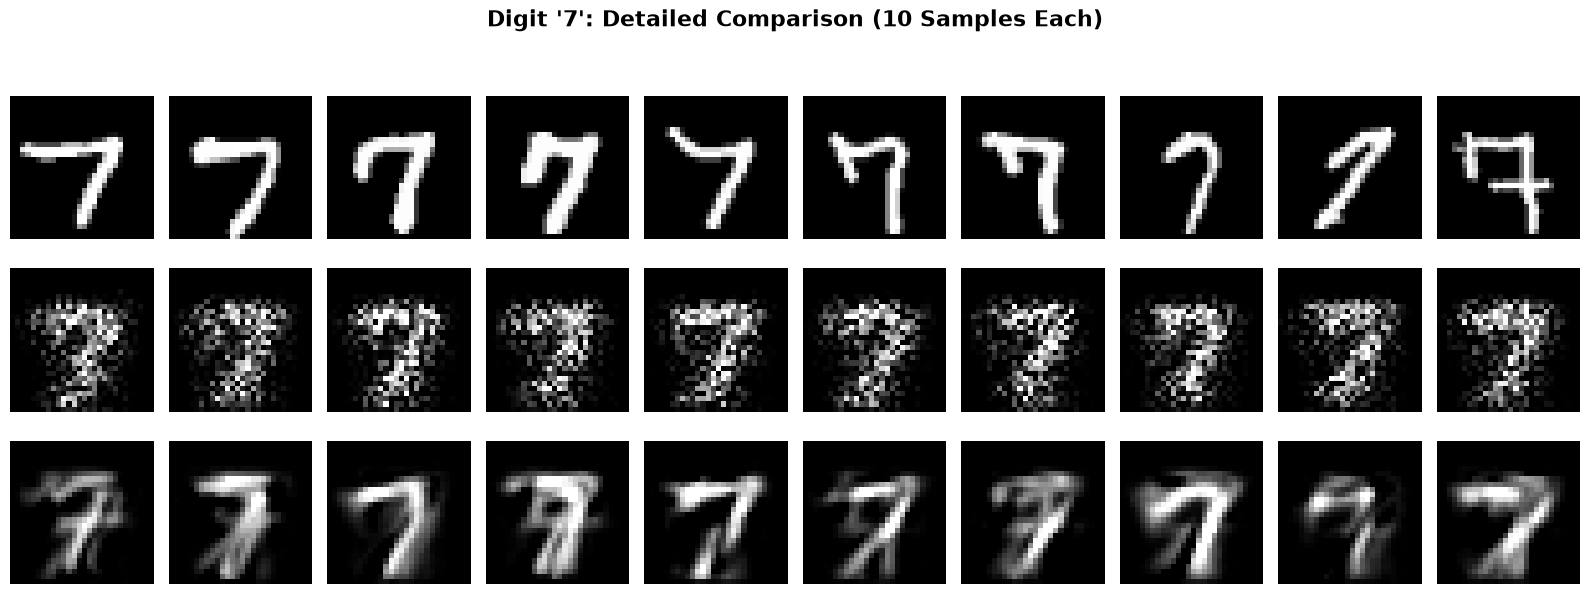

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# ==========================================
# 1. 准备数据与拟合高斯模型
# ==========================================
print("加载 MNIST 数据集...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X = np.asarray(mnist.data, dtype=np.float64) / 255.0
y = np.asarray(mnist.target, dtype=int)

# 使用小样本加速演示
X_train, _, y_train, _ = train_test_split(X, y, train_size=10000, random_state=42, stratify=y)

classes = np.unique(y_train)
mus = {}          # 均值向量
covs = {}         # 协方差矩阵 (完整版，用于采样)
stds = {}         # 标准差向量 (用于朴素贝叶斯采样)

print("为每个数字拟合高斯分布...")
for c in classes:
    X_c = X_train[y_train == c]
    
    # 计算均值
    mu = np.mean(X_c, axis=0)
    mus[c] = mu
    
    # 【关键】计算完整协方差矩阵 (784x784)，用于真实采样
    # 但由于 784 维下矩阵奇异，我们先用 PCA 降维到 50 维再采样
    # 这里先保存原始数据，后面用 PCA 处理
    stds[c] = np.std(X_c, axis=0) + 1e-6  # 用于朴素采样（对角协方差）

# ==========================================
# 2. 两种采样策略对比
# ==========================================

def sample_naive_gaussian(class_label, n_samples=10):
    """策略 1：朴素高斯采样 (对角协方差，假设像素独立)"""
    mu = mus[class_label]
    std = stds[class_label]
    
    # 从独立的 784 个一维高斯分布中采样
    samples = np.random.randn(n_samples, 784) * std + mu
    return np.clip(samples, 0, 1)  # 限制在 [0, 1] 范围内

def sample_pca_gaussian(class_label, n_samples=10, n_components=50):
    """策略 2：PCA + 完整高斯采样 (捕捉像素相关性)"""
    X_c = X_train[y_train == class_label]
    mu = mus[class_label]
    
    # 1. 用 PCA 降维到 50 维
    pca = PCA(n_components=n_components, svd_solver='randomized', random_state=42)
    X_c_pca = pca.fit_transform(X_c - mu)  # 去均值后降维
    
    # 2. 在 50 维空间中拟合高斯分布
    mu_pca = np.mean(X_c_pca, axis=0)
    cov_pca = np.cov(X_c_pca, rowvar=False) + np.eye(n_components) * 1e-6  # 正则化
    
    # 3. 从 50 维高斯分布中采样
    samples_pca = np.random.multivariate_normal(mu_pca, cov_pca, n_samples)
    
    # 4. 逆变换回 784 维空间
    samples = pca.inverse_transform(samples_pca) + mu
    return np.clip(samples, 0, 1)

# ==========================================
# 3. 可视化：真实 vs 生成 (对比两种策略)
# ==========================================

def visualize_comparison(digit_class=5, n_samples=10):
    """可视化真实样本、朴素采样、PCA采样的对比"""
    
    # 获取真实样本
    real_samples = X_train[y_train == digit_class][:n_samples]
    
    # 两种采样策略
    naive_samples = sample_naive_gaussian(digit_class, n_samples)
    pca_samples = sample_pca_gaussian(digit_class, n_samples)
    
    # 创建可视化
    fig = plt.figure(figsize=(18, 6))
    fig.suptitle(f"Digit '{digit_class}': Real vs Generated Samples", 
                 fontsize=20, fontweight='bold', y=1.02)
    
    # --- 左：真实样本 ---
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.imshow(np.hstack([img.reshape(28, 28) for img in real_samples[:5]]), cmap='gray')
    ax1.set_title("Real MNIST Samples\n(Sharp, Diverse, Natural)", fontsize=14, color='green')
    ax1.axis('off')
    
    # --- 中：朴素高斯采样 (对角协方差) ---
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.imshow(np.hstack([img.reshape(28, 28) for img in naive_samples[:5]]), cmap='gray')
    ax2.set_title("Naive Gaussian Sampling\n(Diagonal Covariance)\nBlurry, No Structure", 
                  fontsize=14, color='red')
    ax2.axis('off')
    
    # --- 右：PCA + 完整高斯采样 ---
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.imshow(np.hstack([img.reshape(28, 28) for img in pca_samples[:5]]), cmap='gray')
    ax3.set_title("PCA + Full Gaussian Sampling\n(Captures Correlations)\nSharper, More Realistic", 
                  fontsize=14, color='blue')
    ax3.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 单独展示所有样本的详细对比
    fig2, axes = plt.subplots(3, n_samples, figsize=(16, 6))
    fig2.suptitle(f"Digit '{digit_class}': Detailed Comparison (10 Samples Each)", 
                  fontsize=16, fontweight='bold', y=1.02)
    
    for i in range(n_samples):
        # 真实样本
        axes[0, i].imshow(real_samples[i].reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel("Real Samples", fontsize=12, fontweight='bold', color='green')
        
        # 朴素采样
        axes[1, i].imshow(naive_samples[i].reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel("Naive Gaussian\n(Diagonal Σ)", fontsize=12, fontweight='bold', color='red')
        
        # PCA采样
        axes[2, i].imshow(pca_samples[i].reshape(28, 28), cmap='gray')
        axes[2, i].axis('off')
        if i == 0:
            axes[2, i].set_ylabel("PCA + Full Gaussian\n(Full Σ)", fontsize=12, fontweight='bold', color='blue')
    
    plt.tight_layout()
    plt.show()

# 运行可视化
visualize_comparison(digit_class=7, n_samples=10)

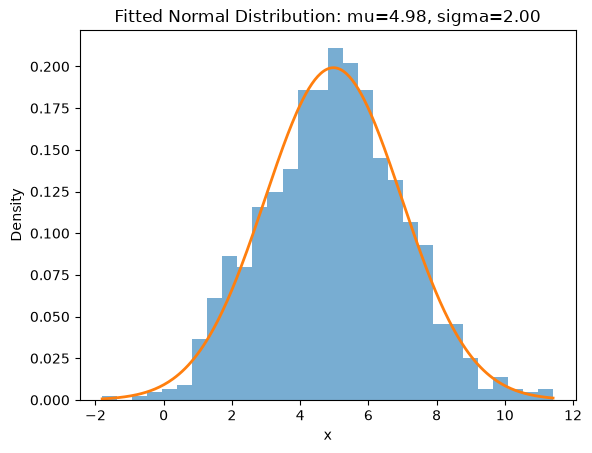

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
data = np.random.normal(loc=5,scale=2,size=1000)
mu = np.mean(data)
sigma = np.std(data)
x = np.linspace(data.min(),data.max(),300)
y = norm.pdf(x,mu,sigma)
plt.hist(data,bins=30,density=True,alpha=0.6)
plt.plot(x,y,linewidth=2)
plt.title(f"Fitted Normal Distribution: mu={mu:.2f}, sigma={sigma:.2f}")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

数据生成完毕: 训练集 (1000, 3), 测试集 (500, 3)

--- 模型 A: 独立正态分布 (对角协方差) ---
拟合均值: [-0.061 -0.062  0.033]
拟合协方差矩阵:
[[0.975 0.    0.   ]
 [0.    1.922 0.   ]
 [0.    0.    1.46 ]]

--- 模型 B: 多元正态分布 (完整协方差) ---
拟合均值: [-0.061 -0.062  0.033]
拟合协方差矩阵:
[[ 0.976  0.792  0.247]
 [ 0.792  1.924 -0.377]
 [ 0.247 -0.377  1.462]]

测试集总对数似然 (越高越好):
模型 A (独立正态): -2437.71
模型 B (多元正态): -2269.08
差距: 模型 B 比模型 A 高 168.63 (说明捕捉相关性极其重要)



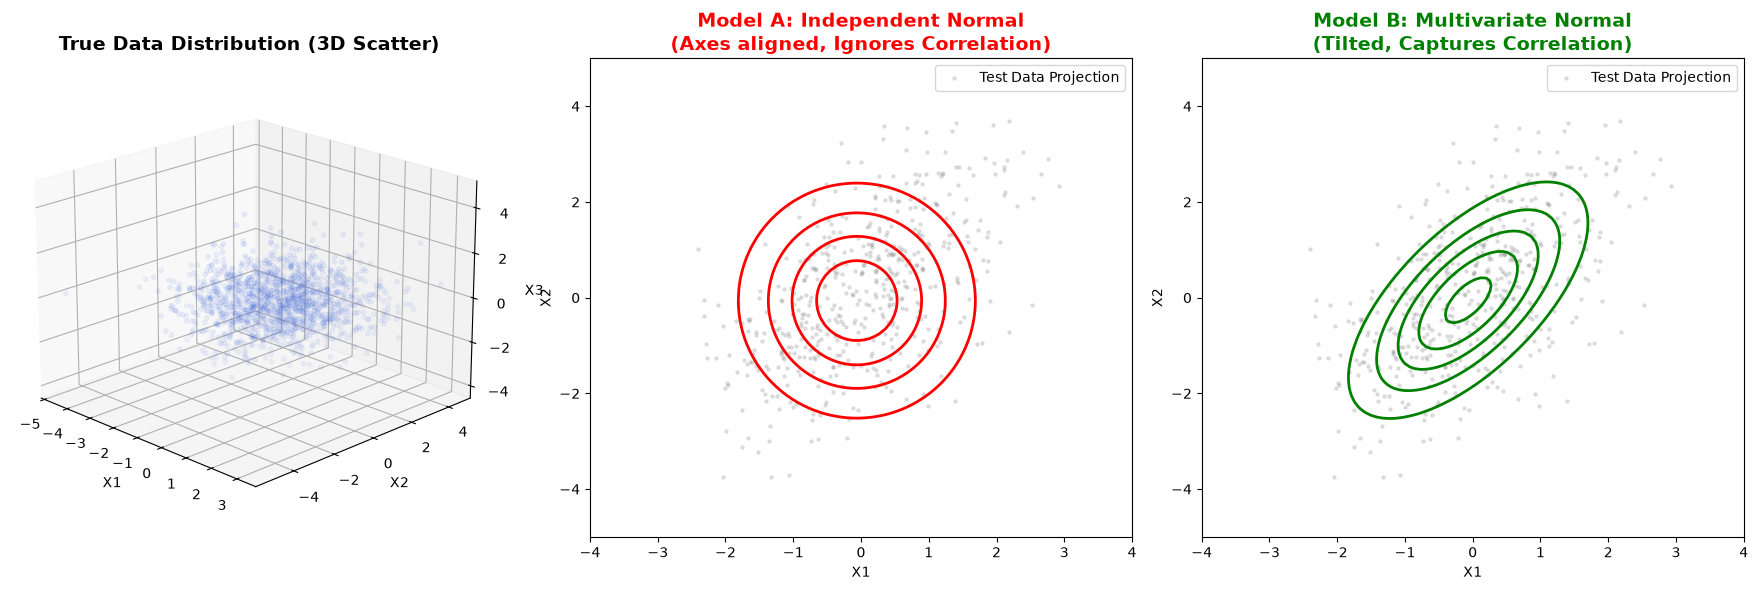

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D

# 设置全局随机种子，保证结果可重复
np.random.seed(42)

# ==========================================
# 1. 生成带有相关性的三维数据集
# ==========================================
# 真实均值向量
true_mu = np.array([0.0, 0.0, 0.0])

# 真实协方差矩阵 (非对角线元素不为0，表示变量间存在相关性)
# X1和X2强正相关(0.8)，X2和X3中等负相关(-0.5)
true_cov = np.array([
    [1.0, 0.8, 0.2],
    [0.8, 2.0, -0.5],
    [0.2, -0.5, 1.5]
])

# 生成 1500 个样本
N_samples = 1500
X = np.random.multivariate_normal(true_mu, true_cov, N_samples)

# 划分训练集和测试集 (用于无偏评估)
X_train, X_test = X[:1000], X[1000:]
print(f"数据生成完毕: 训练集 {X_train.shape}, 测试集 {X_test.shape}\n")


# ==========================================
# 2. 拟合模型 A：独立正态分布模型 (Naive / Independent)
# ==========================================
# 核心假设：X1, X2, X3 相互独立。
# 因此，我们只计算每个维度的边缘方差，强制忽略协方差（非对角线元素设为0）。
mu_indep = np.mean(X_train, axis=0)
var_indep = np.var(X_train, axis=0)
cov_indep = np.diag(var_indep) # 构造对角协方差矩阵

print("--- 模型 A: 独立正态分布 (对角协方差) ---")
print(f"拟合均值: {np.round(mu_indep, 3)}")
print(f"拟合协方差矩阵:\n{np.round(cov_indep, 3)}\n")


# ==========================================
# 3. 拟合模型 B：多元正态分布模型 (Multivariate / Full)
# ==========================================
# 核心假设：变量间存在线性相关性。
# 计算完整的 3x3 协方差矩阵。
mu_multi = np.mean(X_train, axis=0)
cov_multi = np.cov(X_train, rowvar=False) # 计算完整协方差矩阵

print("--- 模型 B: 多元正态分布 (完整协方差) ---")
print(f"拟合均值: {np.round(mu_multi, 3)}")
print(f"拟合协方差矩阵:\n{np.round(cov_multi, 3)}\n")


# ==========================================
# 4. 定量评估：对数似然 (Log-Likelihood)
# ==========================================
# 对数似然越高，说明模型对数据的拟合越好
rv_indep = multivariate_normal(mean=mu_indep, cov=cov_indep)
rv_multi = multivariate_normal(mean=mu_multi, cov=cov_multi)

ll_indep = np.sum(rv_indep.logpdf(X_test))
ll_multi = np.sum(rv_multi.logpdf(X_test))

print("="*40)
print(f"测试集总对数似然 (越高越好):")
print(f"模型 A (独立正态): {ll_indep:.2f}")
print(f"模型 B (多元正态): {ll_multi:.2f}")
print(f"差距: 模型 B 比模型 A 高 {ll_multi - ll_indep:.2f} (说明捕捉相关性极其重要)")
print("="*40 + "\n")


# ==========================================
# 5. 可视化对比
# ==========================================
fig = plt.figure(figsize=(18, 6))

# --- 图 1: 真实数据的 3D 散点图 ---
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], s=10, alpha=0.3, c='royalblue')
ax1.set_title("True Data Distribution (3D Scatter)", fontsize=14, fontweight='bold')
ax1.set_xlabel("X1"); ax1.set_ylabel("X2"); ax1.set_zlabel("X3")
ax1.view_init(elev=20, azim=-45)

# --- 准备 2D 等高线数据 (固定 X3 = 0，观察 X1 和 X2 的切面) ---
x1_grid, x2_grid = np.meshgrid(np.linspace(-4, 4, 100), np.linspace(-5, 5, 100))
pos_grid = np.dstack((x1_grid, x2_grid, np.zeros_like(x1_grid))) # X3 固定为 0

z_indep = rv_indep.pdf(pos_grid)
z_multi = rv_multi.pdf(pos_grid)

# --- 图 2: 独立正态模型的 2D 概率密度等高线 (X3=0 切面) ---
ax2 = fig.add_subplot(1, 3, 2)
# 画出真实数据在 X1-X2 平面的投影作为背景
ax2.scatter(X_test[:, 0], X_test[:, 1], s=5, alpha=0.2, c='gray', label='Test Data Projection')
# 画等高线
cs2 = ax2.contour(x1_grid, x2_grid, z_indep, levels=5, colors='red', linewidths=2)
ax2.set_title("Model A: Independent Normal\n(Axes aligned, Ignores Correlation)", 
              fontsize=14, fontweight='bold', color='red')
ax2.set_xlabel("X1"); ax2.set_ylabel("X2")
ax2.legend()

# --- 图 3: 多元正态模型的 2D 概率密度等高线 (X3=0 切面) ---
ax3 = fig.add_subplot(1, 3, 3)
ax3.scatter(X_test[:, 0], X_test[:, 1], s=5, alpha=0.2, c='gray', label='Test Data Projection')
cs3 = ax3.contour(x1_grid, x2_grid, z_multi, levels=5, colors='green', linewidths=2)
ax3.set_title("Model B: Multivariate Normal\n(Tilted, Captures Correlation)", 
              fontsize=14, fontweight='bold', color='green')
ax3.set_xlabel("X1"); ax3.set_ylabel("X2")
ax3.legend()

plt.tight_layout()
plt.show()

未检测到本地模型，开始加载数据并训练...

开始为 10 个类别拟合 784 维多元高斯模型...
拟合完成！耗时: 2.08 秒

✅ 模型参数已保存至: mnist_mvg_784d_params.pkl (文件大小: 93.9 MB)

正在使用加载的模型预测测试集...
🎯 784维正则化多元高斯模型 准确率: 94.28%



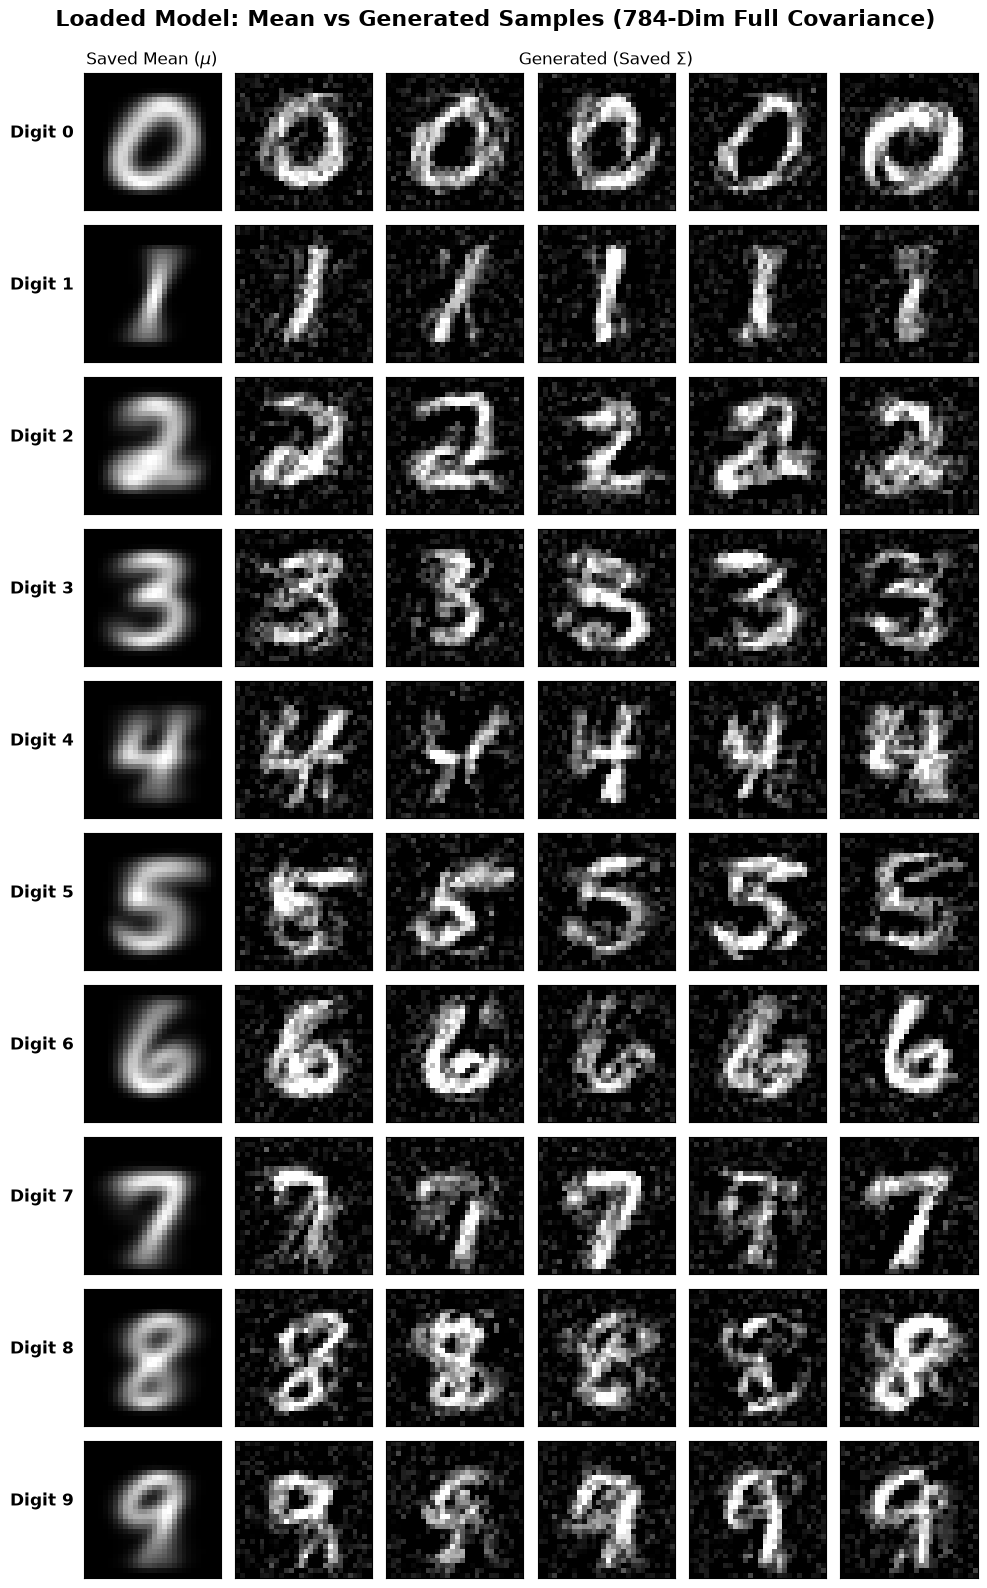

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ==========================================
# 1. 定义支持保存/加载的高维多元高斯分类器
# ==========================================
class HighDimMultivariateGaussian:
    def __init__(self, alpha=0.01):
        self.alpha = alpha
        self.classes = None
        self.mu = {}        # 均值向量 (784,)
        self.sigma = {}     # 正则化协方差矩阵 (784, 784)
        self.sigma_inv = {} # 协方差逆矩阵 (784, 784)
        self.log_det = {}   # 协方差对数行列式 (标量)
        
    def fit(self, X, y):
        self.classes = np.unique(y)
        D = X.shape[1] 
        print(f"开始为 {len(self.classes)} 个类别拟合 784 维多元高斯模型...")
        start_time = time.time()
        
        for c in self.classes:
            X_c = X[y == c]
            self.mu[c] = np.mean(X_c, axis=0)
            cov_sample = np.cov(X_c, rowvar=False) 
            self.sigma[c] = cov_sample + self.alpha * np.eye(D)
            
            # 计算逆矩阵和对数行列式 (最耗时的步骤)
            self.sigma_inv[c] = np.linalg.inv(self.sigma[c])
            sign, logdet = np.linalg.slogdet(self.sigma[c])
            self.log_det[c] = logdet
            
        print(f"拟合完成！耗时: {time.time() - start_time:.2f} 秒\n")

    def save_params(self, filepath):
        """将所有模型参数保存到本地文件"""
        params = {
            'alpha': self.alpha,
            'classes': self.classes,
            'mu': self.mu,
            'sigma': self.sigma,
            'sigma_inv': self.sigma_inv,
            'log_det': self.log_det
        }
        with open(filepath, 'wb') as f:
            pickle.dump(params, f)
        file_size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"✅ 模型参数已保存至: {filepath} (文件大小: {file_size_mb:.1f} MB)\n")

    def load_params(self, filepath):
        """从本地文件加载模型参数，跳过耗时的 fit 过程"""
        with open(filepath, 'rb') as f:
            params = pickle.load(f)
            
        self.alpha = params['alpha']
        self.classes = params['classes']
        self.mu = params['mu']
        self.sigma = params['sigma']
        self.sigma_inv = params['sigma_inv']
        self.log_det = params['log_det']
        print(f"✅ 模型参数已从 {filepath} 加载完毕！\n")
        
    def log_likelihood(self, X):
        N, D = X.shape
        ll = np.zeros((N, len(self.classes)))
        for i, c in enumerate(self.classes):
            diff = X - self.mu[c] 
            mahal = np.einsum('ij,jk,ik->i', diff, self.sigma_inv[c], diff)
            ll[:, i] = -0.5 * (D * np.log(2 * np.pi) + self.log_det[c] + mahal)
        return ll
        
    def predict(self, X):
        ll = self.log_likelihood(X)
        return self.classes[np.argmax(ll, axis=1)]

    def sample(self, class_label, n_samples=5, seed=42):
        rng = np.random.default_rng(seed)
        samples = rng.multivariate_normal(
            mean=self.mu[class_label], 
            cov=self.sigma[class_label], 
            size=n_samples
        )
        return np.clip(samples, 0, 1)

# ==========================================
# 2. 主程序：训练、保存、加载与验证
# ==========================================
if __name__ == "__main__":
    MODEL_PATH = "mnist_mvg_784d_params.pkl"
    
    # 检查是否已经存在保存的模型
    if os.path.exists(MODEL_PATH):
        print("检测到本地已保存的模型，直接加载...\n")
        model = HighDimMultivariateGaussian()
        model.load_params(MODEL_PATH)
    else:
        print("未检测到本地模型，开始加载数据并训练...\n")
        # 加载数据 (为了演示速度，这里使用了较小的训练集，实际可调大)
        mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
        X = np.asarray(mnist.data, dtype=np.float64) / 255.0
        y = np.asarray(mnist.target, dtype=int)
        
        # 取 20000 个样本用于训练，加速协方差矩阵计算
        X_train, _, y_train, _ = train_test_split(X, y, train_size=20000, random_state=42, stratify=y)
        _, X_test, _, y_test = train_test_split(X, y, test_size=5000, random_state=42, stratify=y)
        
        # 训练并保存
        model = HighDimMultivariateGaussian(alpha=0.01)
        model.fit(X_train, y_train)
        model.save_params(MODEL_PATH)

    # ==========================================
    # 3. 验证加载后的模型性能 (分类与采样)
    # ==========================================
    print("正在使用加载的模型预测测试集...")
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"🎯 784维正则化多元高斯模型 准确率: {acc * 100:.2f}%\n")

    # 可视化：展示保存的均值和协方差生成的样本
    fig, axes = plt.subplots(10, 6, figsize=(10, 16))
    fig.suptitle("Loaded Model: Mean vs Generated Samples (784-Dim Full Covariance)", 
                 fontsize=16, fontweight='bold', y=0.99)

    for i, c in enumerate(model.classes):
        # 列 0: 保存的均值图像
        axes[i, 0].imshow(model.mu[c].reshape(28, 28), cmap='gray')
        axes[i, 0].set_ylabel(f"Digit {c}", fontsize=12, fontweight='bold', rotation=0, labelpad=30)
        axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])
        if i == 0: axes[i, 0].set_title("Saved Mean ($\mu$)", fontsize=12)
        
        # 列 1-5: 使用保存的协方差矩阵采样
        generated_samples = model.sample(c, n_samples=5, seed=42+i)
        for j in range(5):
            axes[i, j+1].imshow(generated_samples[j].reshape(28, 28), cmap='gray')
            axes[i, j+1].set_xticks([]); axes[i, j+1].set_yticks([])
            if i == 0 and j == 2: axes[i, j+1].set_title("Generated (Saved $\Sigma$)", fontsize=12)

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

正在加载 MNIST 数据集...
训练集: (56000, 784), 测试集: (14000, 784)

开始为 10 个类别拟合独立像素高斯模型...
拟合完成！耗时: 0.24 秒 (极快，因为无需计算矩阵逆)

正在预测测试集...
🎯 独立像素高斯模型 (Gaussian Naive Bayes) 准确率: 56.49%



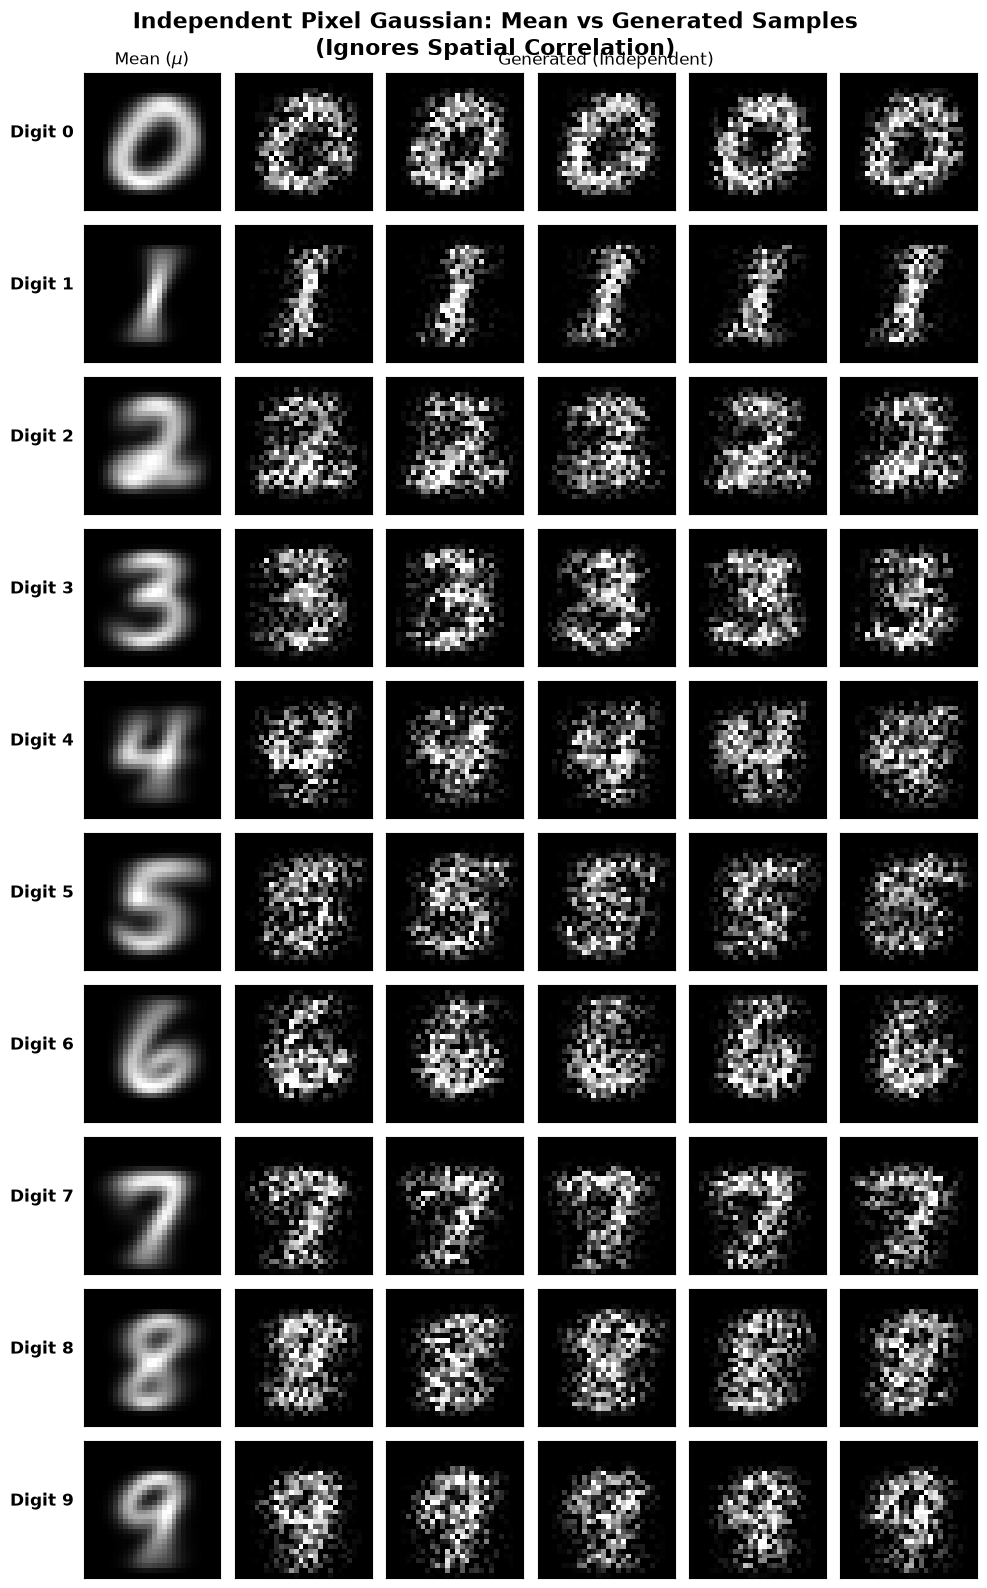

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ==========================================
# 1. 加载数据与预处理
# ==========================================
print("正在加载 MNIST 数据集...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X = np.asarray(mnist.data, dtype=np.float64) / 255.0
y = np.asarray(mnist.target, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}\n")

# ==========================================
# 2. 定义独立像素高斯模型 (对角协方差)
# ==========================================
class IndependentPixelGaussian:
    def __init__(self, epsilon=1e-9):
        """
        epsilon: 平滑系数。防止某些背景像素方差为0导致除以0报错。
        """
        self.epsilon = epsilon
        self.classes = None
        self.mu = {}       # 均值向量 (784,)
        self.var = {}      # 方差向量 (784,) - 注意：不是矩阵！
        self.log_var = {}  # 方差的对数 (用于加速对数似然计算)
        
    def fit(self, X, y):
        self.classes = np.unique(y)
        print(f"开始为 {len(self.classes)} 个类别拟合独立像素高斯模型...")
        start_time = time.time()
        
        for c in self.classes:
            X_c = X[y == c]
            # 1. 计算每个像素的均值
            self.mu[c] = np.mean(X_c, axis=0)
            
            # 2. 计算每个像素的方差 (忽略协方差)
            # 加上 epsilon 防止方差为 0 (例如图像四个角落的纯黑像素)
            self.var[c] = np.var(X_c, axis=0) + self.epsilon
            self.log_var[c] = np.log(self.var[c])
            
        print(f"拟合完成！耗时: {time.time() - start_time:.2f} 秒 (极快，因为无需计算矩阵逆)\n")
        
    def log_likelihood(self, X):
        """计算每个样本属于每个类别的对数似然"""
        N, D = X.shape
        ll = np.zeros((N, len(self.classes)))
        
        for i, c in enumerate(self.classes):
            diff = X - self.mu[c] # (N, 784)
            
            # 独立高斯的对数概率密度公式：
            # log P(x) = sum_j [ -0.5 * log(2*pi) - 0.5 * log(var_j) - 0.5 * (x_j - mu_j)^2 / var_j ]
            # 利用广播机制进行高效的批量计算
            log_prob = -0.5 * (np.log(2 * np.pi) + self.log_var[c] + (diff ** 2) / self.var[c])
            
            # 因为假设像素独立，联合对数概率等于各个像素对数概率的“求和”
            ll[:, i] = np.sum(log_prob, axis=1)
            
        return ll
        
    def predict(self, X):
        """预测类别"""
        ll = self.log_likelihood(X)
        return self.classes[np.argmax(ll, axis=1)]

    def sample(self, class_label, n_samples=5, seed=42):
        """从独立高斯分布中采样生成图像"""
        rng = np.random.default_rng(seed)
        samples = np.zeros((n_samples, 784))
        
        # 【核心区别】：对每个像素独立进行一维高斯采样
        for j in range(784):
            samples[:, j] = rng.normal(
                loc=self.mu[class_label][j], 
                scale=np.sqrt(self.var[class_label][j]), 
                size=n_samples
            )
        return np.clip(samples, 0, 1)

# ==========================================
# 3. 训练与评估
# ==========================================
ipg_model = IndependentPixelGaussian(epsilon=1e-9)
ipg_model.fit(X_train, y_train)

print("正在预测测试集...")
y_pred = ipg_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"🎯 独立像素高斯模型 (Gaussian Naive Bayes) 准确率: {acc * 100:.2f}%\n")

# ==========================================
# 4. 采样生成图像 (观察“独立假设”的视觉缺陷)
# ==========================================
fig, axes = plt.subplots(10, 6, figsize=(10, 16))
fig.suptitle("Independent Pixel Gaussian: Mean vs Generated Samples\n(Ignores Spatial Correlation)", 
             fontsize=16, fontweight='bold', y=0.99)

for i, c in enumerate(ipg_model.classes):
    # 列 0: 均值图像
    axes[i, 0].imshow(ipg_model.mu[c].reshape(28, 28), cmap='gray')
    axes[i, 0].set_ylabel(f"Digit {c}", fontsize=12, fontweight='bold', rotation=0, labelpad=30)
    axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])
    if i == 0: axes[i, 0].set_title("Mean ($\mu$)", fontsize=12)
    
    # 列 1-5: 独立采样生成的图像
    generated_samples = ipg_model.sample(c, n_samples=5, seed=42+i)
    for j in range(5):
        axes[i, j+1].imshow(generated_samples[j].reshape(28, 28), cmap='gray')
        axes[i, j+1].set_xticks([]); axes[i, j+1].set_yticks([])
        if i == 0 and j == 2: axes[i, j+1].set_title("Generated (Independent)", fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import os
import time
from sklearn.datasets import fetch_openml

# ==========================================
# 1. 环境配置与数据加载
# ==========================================
# 创建保存图像的目录
SAVE_DIR = "mnist_statistical_analysis"
os.makedirs(SAVE_DIR, exist_ok=True)

# 设置全局绘图风格
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False 

print("正在加载 MNIST 数据集 (首次运行需下载，请耐心等待)...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X = np.asarray(mnist.data, dtype=np.float64) / 255.0
y = np.asarray(mnist.target, dtype=int)
print(f"数据加载完成！共 {X.shape[0]} 个样本，维度 {X.shape[1]}。\n")

# 选定 5 个具有代表性的像素点 (将 28x28 映射到 784 维)
# 1. 中心点 (14,14) 2. 左上背景 (4,4) 3. 顶部笔画区 (8,14) 4. 底部笔画区 (20,14) 5. 右侧边缘 (14,22)
selected_pixels_2d = [(14, 14), (4, 4), (8, 14), (20, 14), (14, 22)]
selected_pixels_1d = [r * 28 + c for r, c in selected_pixels_2d]
pixel_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00'] # 5种不同颜色

# ==========================================
# 2. 核心绘图函数：为单个数字生成 6 合 1 分析面板
# ==========================================
def generate_dashboard(digit, X_digit):
    print(f"正在计算数字 [{digit}] 的统计量并生成面板...")
    
    # --- 统计量计算 ---
    mu = np.mean(X_digit, axis=0)             # 均值向量 (784,)
    std = np.std(X_digit, axis=0)             # 标准差向量 (784,)
    # 计算协方差矩阵 (784x784)，对于6000个样本，这步大约需要1-2秒
    cov = np.cov(X_digit, rowvar=False)       
    
    mu_2d = mu.reshape(28, 28)
    std_2d = std.reshape(28, 28)

    # --- 画布与布局设置 ---
    fig = plt.figure(figsize=(22, 12))
    fig.suptitle(f"Statistical Analysis Dashboard for Digit '{digit}'  (N={X_digit.shape[0]} samples)", 
                 fontsize=24, fontweight='bold', y=0.98)
    
    # 使用 GridSpec 进行精细布局: 2行, 带有宽度比例调整
    gs = gridspec.GridSpec(2, 6, height_ratios=[1, 1], width_ratios=[1, 1, 1.2, 0.8, 0.8, 1.5], 
                           hspace=0.35, wspace=0.3)

    # ==========================================
    # 子图 1: 平均图像 (Mean Image)
    # ==========================================
    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.imshow(mu_2d, cmap='viridis')
    ax1.set_title("1. Mean Image ($\mu$)", fontsize=16, fontweight='bold')
    ax1.axis('off')
    # 在均值图上标记选定的 5 个像素点
    for i, (r, c) in enumerate(selected_pixels_2d):
        ax1.plot(c, r, marker='s', markersize=6, color=pixel_colors[i], markeredgecolor='white', markeredgewidth=1)
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label='Pixel Intensity')

    # ==========================================
    # 子图 2: 标准差图像 (Std Dev Image)
    # ==========================================
    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.imshow(std_2d, cmap='magma')
    ax2.set_title("2. Standard Deviation Image ($\sigma$)", fontsize=16, fontweight='bold')
    ax2.axis('off')
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label='Variation Level')

    # ==========================================
    # 子图 3: 协方差热图 (Covariance Heatmap)
    # ==========================================
    ax3 = fig.add_subplot(gs[0, 2:4]) # 占据更宽的区域
    # 使用对称的 colormap 突出正负相关性
    vmax = np.percentile(np.abs(cov), 99) # 截断极值，让热图更清晰
    im3 = ax3.imshow(cov, cmap='coolwarm', vmin=-vmax, vmax=vmax, interpolation='nearest')
    ax3.set_title("5. Covariance Matrix Heatmap ($\Sigma$)\n784×784 Pixel Correlations", fontsize=16, fontweight='bold')
    ax3.set_xlabel("Pixel Index (0 to 783)", fontsize=12)
    ax3.set_ylabel("Pixel Index (0 to 783)", fontsize=12)
    fig.colorbar(im3, ax=ax3, label='Covariance Value')

    # ==========================================
    # 子图 4: 像素均值曲线 (Pixel Mean Curve)
    # ==========================================
    ax4 = fig.add_subplot(gs[1, 0:2])
    ax4.plot(mu, color='#2ca02c', linewidth=1.5, alpha=0.8)
    ax4.fill_between(range(784), mu, alpha=0.2, color='#2ca02c')
    # 标记选定的5个像素
    for i, idx in enumerate(selected_pixels_1d):
        ax4.axvline(idx, color=pixel_colors[i], linestyle='--', alpha=0.6, linewidth=1)
        ax4.plot(idx, mu[idx], marker='o', color=pixel_colors[i], markersize=8, zorder=5)
    ax4.set_title("3. Pixel Mean Curve (1D Flattened $\mu$)", fontsize=16, fontweight='bold')
    ax4.set_xlabel("Pixel Index (0 to 783)", fontsize=12)
    ax4.set_ylabel("Mean Intensity", fontsize=12)
    ax4.set_xlim(0, 783)
    ax4.grid(True, alpha=0.3)

    # ==========================================
    # 子图 5: 像素标准差曲线 (Pixel Std Dev Curve)
    # ==========================================
    ax5 = fig.add_subplot(gs[1, 2:4])
    ax5.plot(std, color='#d62728', linewidth=1.5, alpha=0.8)
    ax5.fill_between(range(784), std, alpha=0.2, color='#d62728')
    for i, idx in enumerate(selected_pixels_1d):
        ax5.axvline(idx, color=pixel_colors[i], linestyle='--', alpha=0.6, linewidth=1)
        ax5.plot(idx, std[idx], marker='o', color=pixel_colors[i], markersize=8, zorder=5)
    ax5.set_title("4. Pixel Standard Deviation Curve (1D Flattened $\sigma$)", fontsize=16, fontweight='bold')
    ax5.set_xlabel("Pixel Index (0 to 783)", fontsize=12)
    ax5.set_ylabel("Standard Deviation", fontsize=12)
    ax5.set_xlim(0, 783)
    ax5.grid(True, alpha=0.3)

    # ==========================================
    # 子图 6: 5 个选定像素的一维分布图
    # ==========================================
    ax6 = fig.add_subplot(gs[:, 4:6]) # 占据右侧两行，提供充足空间
    for i, (idx, (r, c)) in enumerate(zip(selected_pixels_1d, selected_pixels_2d)):
        pixel_values = X_digit[:, idx]
        # 绘制直方图与核密度估计 (KDE) 的近似
        ax6.hist(pixel_values, bins=30, density=True, alpha=0.4, color=pixel_colors[i], 
                 label=f'Pixel [{r},{c}] (Idx {idx})', edgecolor='black', linewidth=0.5)
        # 简单的 KDE 平滑曲线
        from scipy.stats import gaussian_kde
        if np.std(pixel_values) > 1e-5: # 防止方差为0报错
            kde = gaussian_kde(pixel_values)
            x_range = np.linspace(0, 1, 200)
            ax6.plot(x_range, kde(x_range), color=pixel_colors[i], linewidth=2.5)
        else:
            ax6.axvline(pixel_values[0], color=pixel_colors[i], linewidth=2.5, linestyle='--')

    ax6.set_title("6. 1D Intensity Distributions of 5 Selected Pixels", fontsize=16, fontweight='bold')
    ax6.set_xlabel("Pixel Intensity Value (0.0 to 1.0)", fontsize=12)
    ax6.set_ylabel("Probability Density", fontsize=12)
    ax6.legend(fontsize=11, loc='upper right')
    ax6.set_xlim(-0.05, 1.05)
    ax6.grid(True, alpha=0.3)

    # --- 保存与清理 ---
    save_path = os.path.join(SAVE_DIR, f"dashboard_digit_{digit}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"  -> 面板已保存至: {save_path}")
    plt.close(fig) # 关闭画布，释放内存

# ==========================================
# 3. 主程序：遍历所有数字并生成
# ==========================================
if __name__ == "__main__":
    start_time = time.time()
    
    for digit in range(10):
        X_digit = X[y == digit]
        generate_dashboard(digit, X_digit)
        
    print(f"\n🎉 全部 10 个数字的分析面板生成完毕！")
    print(f"总耗时: {time.time() - start_time:.2f} 秒")
    print(f"请查看当前目录下的 [{SAVE_DIR}] 文件夹获取高清图片。")

正在加载 MNIST 数据集 (首次运行需下载，请耐心等待)...
数据加载完成！共 70000 个样本，维度 784。

正在计算数字 [0] 的统计量并生成面板...
  -> 面板已保存至: mnist_statistical_analysis\dashboard_digit_0.png
正在计算数字 [1] 的统计量并生成面板...
  -> 面板已保存至: mnist_statistical_analysis\dashboard_digit_1.png
正在计算数字 [2] 的统计量并生成面板...
  -> 面板已保存至: mnist_statistical_analysis\dashboard_digit_2.png
正在计算数字 [3] 的统计量并生成面板...
  -> 面板已保存至: mnist_statistical_analysis\dashboard_digit_3.png
正在计算数字 [4] 的统计量并生成面板...
  -> 面板已保存至: mnist_statistical_analysis\dashboard_digit_4.png
正在计算数字 [5] 的统计量并生成面板...
  -> 面板已保存至: mnist_statistical_analysis\dashboard_digit_5.png
正在计算数字 [6] 的统计量并生成面板...
  -> 面板已保存至: mnist_statistical_analysis\dashboard_digit_6.png
正在计算数字 [7] 的统计量并生成面板...
  -> 面板已保存至: mnist_statistical_analysis\dashboard_digit_7.png
正在计算数字 [8] 的统计量并生成面板...
  -> 面板已保存至: mnist_statistical_analysis\dashboard_digit_8.png
正在计算数字 [9] 的统计量并生成面板...
  -> 面板已保存至: mnist_statistical_analysis\dashboard_digit_9.png

🎉 全部 10 个数字的分析面板生成完毕！
总耗时: 13.03 秒
请查看当前目录下的 [mnist_statistical_analysis] 文件夹

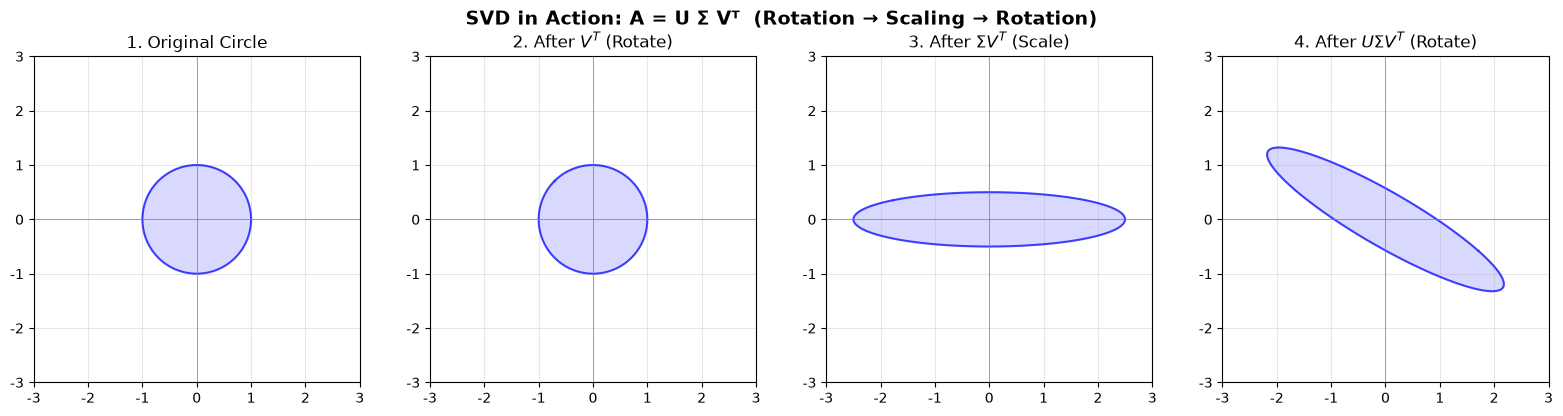

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 原始点：一个单位圆上的点
theta = np.linspace(0, 2*np.pi, 100)
circle = np.vstack([np.cos(theta), np.sin(theta)])  # 2 x 100

# 2. 构造一个变换矩阵 A（2x2），人为设计旋转和拉伸
angle1, angle2 = np.pi/4, -np.pi/6  # 旋转角度
scale1, scale2 = 2.5, 0.5           # 沿两个轴的拉伸倍数

U = np.array([[np.cos(angle2), -np.sin(angle2)],
              [np.sin(angle2),  np.cos(angle2)]])
Sigma = np.diag([scale1, scale2])
VT = np.array([[np.cos(angle1), -np.sin(angle1)],
               [np.sin(angle1),  np.cos(angle1)]])

A = U @ Sigma @ VT  # 这就是我们要分解的矩阵

# 3. 应用变换
transformed = A @ circle

# 4. SVD 分解（numpy 会自动算）
U_svd, S_svd, VT_svd = np.linalg.svd(A)

# 5. 绘制四个阶段
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = [
    "1. Original Circle",
    "2. After $V^T$ (Rotate)",
    "3. After $Σ V^T$ (Scale)",
    "4. After $U Σ V^T$ (Rotate)"
]

# 阶段数据
step0 = circle                           # 原圆
step1 = VT_svd @ circle                  # 旋转
step2 = np.diag(S_svd) @ step1           # 伸缩
step3 = U_svd @ step2                    # 旋转 = 最终椭圆

steps = [step0, step1, step2, step3]

for ax, data, title in zip(axes, steps, titles):
    ax.plot(data[0], data[1], 'b-', alpha=0.7)
    ax.fill(data[0], data[1], alpha=0.15, color='blue')
    ax.axhline(0, color='grey', lw=0.5)
    ax.axvline(0, color='grey', lw=0.5)
    ax.set_aspect('equal')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)

plt.suptitle("SVD in Action: A = U Σ Vᵀ  (Rotation → Scaling → Rotation)", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

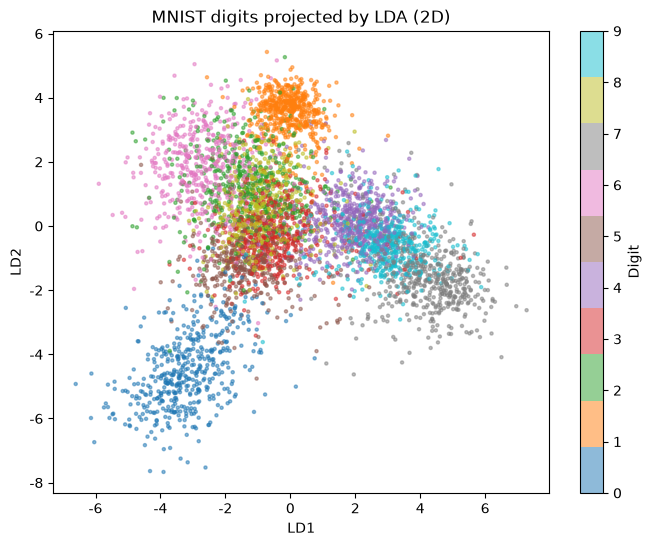

In [31]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

# 加载 MNIST (多类)
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X, y = mnist.data[:5000] / 255.0, mnist.target[:5000].astype(int)

# LDA 降到 2 维（因为 10 类，最多能降到 9 维，选 2 维便于可视化）
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X, y)

# 画出投影后的分布
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_lda[:,0], X_lda[:,1], c=y, cmap='tab10', alpha=0.5, s=5)
plt.colorbar(scatter, label='Digit')
plt.title('MNIST digits projected by LDA (2D)')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.show()

正在加载 Olivetti 人脸数据集 (如果是首次运行，可能会自动下载 .pkz 文件)...
数据加载成功！总样本数: 400, 图像维度: 4096
训练集大小: 280, 测试集大小: 120
开始训练 EigenFace (保留 40 个主成分)...
训练完成！
正在生成可视化图像...


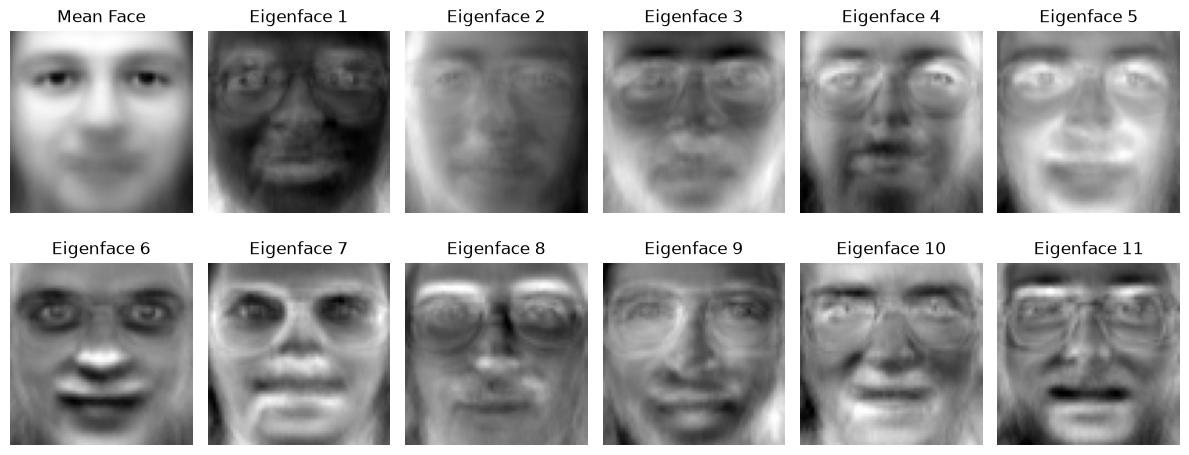

正在进行测试集预测...
------------------------------
测试集总数: 120
预测正确数: 106
最终识别准确率: 88.33%
------------------------------


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# ================= 1. 数据加载与划分 =================
def load_and_split_data():
    """
    使用 sklearn 加载 Olivetti 人脸数据集 (底层自动处理 .pkz 文件)
    并划分为训练集和测试集。
    """
    print("正在加载 Olivetti 人脸数据集 (如果是首次运行，可能会自动下载 .pkz 文件)...")
    # shuffle=False 保证数据按 0-39 号人物的顺序排列，每人10张
    faces = fetch_olivetti_faces(shuffle=False, random_state=0)
    
    X = faces.data      # 形状: (400, 4096)，400张图，每张 64x64 展平
    y = faces.target    # 形状: (400,)，标签 0-39
    img_shape = (64, 64)
    
    print(f"数据加载成功！总样本数: {X.shape[0]}, 图像维度: {X.shape[1]}")
    
    # 划分训练集和测试集
    # 数据集结构：40个人，每人10张图。我们取每人前7张做训练，后3张做测试。
    X_train, y_train = [], []
    X_test, y_test = [], []
    
    for i in range(40): # 遍历 40 个人
        start_idx = i * 10
        # 前 7 张用于训练
        X_train.extend(X[start_idx : start_idx + 7])
        y_train.extend(y[start_idx : start_idx + 7])
        # 后 3 张用于测试
        X_test.extend(X[start_idx + 7 : start_idx + 10])
        y_test.extend(y[start_idx + 7 : start_idx + 10])
        
    X_train = np.array(X_train, dtype=np.float32)
    y_train = np.array(y_train)
    X_test = np.array(X_test, dtype=np.float32)
    y_test = np.array(y_test)
    
    print(f"训练集大小: {X_train.shape[0]}, 测试集大小: {X_test.shape[0]}")
    return X_train, y_train, X_test, y_test, img_shape


# ================= 2. EigenFace 核心算法 =================
class EigenFaceRecognizer:
    def __init__(self, num_components=40):
        """
        :param num_components: 保留的主成分（特征脸）数量 K
        """
        self.num_components = num_components
        self.mean_face = None
        self.eigenfaces = None
        self.train_weights = None
        self.train_labels = None
        self.img_size = None

    def train(self, X_train, y_train, img_size):
        self.train_labels = y_train
        self.img_size = img_size
        num_samples, num_pixels = X_train.shape
        
        print(f"开始训练 EigenFace (保留 {self.num_components} 个主成分)...")
        
        # 1. 计算平均脸
        self.mean_face = np.mean(X_train, axis=0)
        
        # 2. 中心化数据 (构建矩阵 A)
        # A 的形状: (num_samples, num_pixels) -> (280, 4096)
        A = X_train - self.mean_face 
        
        # 3. 计算特征脸 (使用小矩阵技巧，避免计算 4096x4096 的协方差矩阵)
        # 计算 L = A * A^T (形状: num_samples x num_samples -> 280x280)
        L = np.dot(A, A.T) 
        
        # 求 L 的特征值和特征向量
        # eigh 专门用于对称矩阵，比 eig 更稳定且返回已排序的特征值
        eigenvalues, eigenvectors = np.linalg.eigh(L)
        
        # eigh 返回的特征值是从小到大排列的，我们需要反转使其从大到小
        idx = np.argsort(eigenvalues)[::-1]
        eigenvectors = eigenvectors[:, idx]
        
        # 取前 K 个特征向量 (形状: 280 x K)
        eigenvectors_small = eigenvectors[:, :self.num_components]
        
        # 4. 映射回原图像空间: U = A^T * V
        # U 的形状: (num_pixels, num_components) -> (4096, K)
        U = np.dot(A.T, eigenvectors_small)
        
        # 对每一列（每一个特征脸）进行 L2 归一化
        for i in range(self.num_components):
            norm = np.linalg.norm(U[:, i])
            if norm > 0:
                U[:, i] = U[:, i] / norm
            
        # 转置以便后续矩阵乘法，形状变为: (K, num_pixels)
        self.eigenfaces = U.T 
        
        # 5. 将训练集投影到特征脸空间，保存权重用于后续比对
        self.train_weights = self.project(X_train)
        print("训练完成！")

    def project(self, X):
        """将图像投影到特征脸空间，得到权重向量 (坐标)"""
        # X_centered 形状: (N, num_pixels)
        # eigenfaces 形状: (K, num_pixels)
        # 返回权重形状: (N, K)
        X_centered = X - self.mean_face
        return np.dot(X_centered, self.eigenfaces.T)

    def predict(self, X_test):
        """通过最近邻分类器 (1-NN) 预测测试集"""
        test_weights = self.project(X_test)
        predictions = []
        
        for tw in test_weights:
            # 计算当前测试样本权重与所有训练样本权重的欧氏距离
            distances = np.linalg.norm(self.train_weights - tw, axis=1)
            # 找到距离最近的训练样本的索引
            nearest_idx = np.argmin(distances)
            # 返回该训练样本的标签
            predictions.append(self.train_labels[nearest_idx])
            
        return np.array(predictions)


# ================= 3. 可视化函数 =================
def visualize(mean_face, eigenfaces, img_size, num_to_show=11):
    """可视化平均脸和前几个特征脸"""
    cols = 6
    rows = int(np.ceil((num_to_show + 1) / cols))
    plt.figure(figsize=(12, rows * 2.5))
    
    # 画平均脸
    plt.subplot(rows, cols, 1)
    # sklearn 的 olivetti 数据像素值在 0~1 之间，matplotlib 可以直接渲染
    plt.imshow(mean_face.reshape(img_size), cmap='gray')
    plt.title("Mean Face")
    plt.axis('off')
    
    # 画前 N 个特征脸
    for i in range(num_to_show):
        plt.subplot(rows, cols, i + 2)
        ef = eigenfaces[i].reshape(img_size)
        # 为了显示对比度更明显，将特征脸归一化到 0-1 之间
        ef_norm = (ef - ef.min()) / (ef.max() - ef.min())
        plt.imshow(ef_norm, cmap='gray')
        plt.title(f"Eigenface {i+1}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()


# ================= 4. 主程序 =================
if __name__ == "__main__":
    # 1. 加载并划分数据
    X_train, y_train, X_test, y_test, img_shape = load_and_split_data()
    
    # 2. 初始化并训练模型
    # 4096维的数据，保留 40 个主成分通常足够捕捉主要特征
    K = 40 
    recognizer = EigenFaceRecognizer(num_components=K)
    recognizer.train(X_train, y_train, img_shape)
    
    # 3. 可视化平均脸和前 11 个特征脸
    print("正在生成可视化图像...")
    visualize(recognizer.mean_face, recognizer.eigenfaces, img_shape, num_to_show=11)
    
    # 4. 测试识别准确率
    print("正在进行测试集预测...")
    y_pred = recognizer.predict(X_test)
    
    # 计算准确率
    accuracy = np.mean(y_pred == y_test)
    print("-" * 30)
    print(f"测试集总数: {len(y_test)}")
    print(f"预测正确数: {np.sum(y_pred == y_test)}")
    print(f"最终识别准确率: {accuracy * 100:.2f}%")
    print("-" * 30)